In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

In [ ]:
%matplotlib inline

In [ ]:
class EncodedImageDataset(Dataset):
    def __init__(self, images, weights, traj_joint, traj_task):
        self.images = images
        self.weights = weights
        self.traj_joint = traj_joint
        self.traj_task = traj_task

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        weight = self.weights[idx]
        traj_joint = self.traj_joint[idx]
        traj_task = self.traj_task[idx]
        return image, weight, traj_joint, traj_task

In [ ]:
def custom_collate_fn(batch):
    images, weights, traj_joint, traj_task = zip(*batch)

    # Stacking images and weights
    images = torch.stack(images)
    weights = torch.stack(weights)

    # Function to get tensor dimensions safely
    def get_dims(tensor):
        if tensor.dim() == 2:
            return tensor.size(0), tensor.size(1), 1
        elif tensor.dim() == 3:
            return tensor.size(0), tensor.size(1), tensor.size(2)
        else:
            raise ValueError(f"Unexpected tensor dimension: {tensor.dim()}")

    # Finding max dimensions for joint and task trajectories
    max_joint_len = max(get_dims(tj)[0] for tj in traj_joint)
    max_joint_features = max(get_dims(tj)[1] for tj in traj_joint)
    max_task_len = max(get_dims(tt)[0] for tt in traj_task)
    max_task_features = max(get_dims(tt)[1] for tt in traj_task)

    # Pad and stack joint trajectories
    padded_traj_joint = torch.stack([
        F.pad(tj if tj.dim() == 3 else tj.unsqueeze(-1),
              (0, max(0, 7 - get_dims(tj)[2]),
               0, max(0, max_joint_features - get_dims(tj)[1]),
               0, max(0, max_joint_len - get_dims(tj)[0])))
        for tj in traj_joint
    ])

    # Pad and stack task trajectories
    padded_traj_task = torch.stack([
        F.pad(tt if tt.dim() == 3 else tt.unsqueeze(-1),
              (0, max(0, 6 - get_dims(tt)[2]),
               0, max(0, max_task_features - get_dims(tt)[1]),
               0, max(0, max_task_len - get_dims(tt)[0])))
        for tt in traj_task
    ])

    return images, weights, padded_traj_joint, padded_traj_task

In [ ]:
class FullyConnectedModel(nn.Module):
    def __init__(self, input_size):
        super(FullyConnectedModel, self).__init__()
        self.fc_layers = nn.Sequential(
            nn.Linear(input_size, 2816),
            nn.ReLU(),
            nn.Linear(2816, 2560),
            nn.ReLU(),
            nn.Linear(2560, 2304),
            nn.ReLU(),
            nn.Linear(2304, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1792),
            nn.ReLU(),
            nn.Linear(1792, 1536),
            nn.ReLU(),
            nn.Linear(1536, 1280),
            nn.ReLU(),
            nn.Linear(1280, 1024),
            nn.ReLU(),
            nn.Linear(1024, 768),
            nn.ReLU(),
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

    def forward(self, x):
        return self.fc_layers(x)

In [ ]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(64 * 8 * 8, 256)  # 32x32 input -> 16x16 after first pool -> 8x8 after second pool

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc(x))
        return x

In [ ]:
class HybridModel(nn.Module):
    def __init__(self, joint_weight_size):
        super(HybridModel, self).__init__()
        self.cnn_model = CNNModel()
        self.fc_joint = nn.Linear(7, 64)
        self.fc_task = nn.Linear(6, 64)

        # Calculate the size of the concatenated features
        cnn_output_size = 256
        joint_output_size = 64
        task_output_size = 64
        total_output_size = cnn_output_size + joint_output_size + task_output_size

        self.fc_final = nn.Linear(total_output_size, joint_weight_size)

    def forward(self, visual_input, traj_joint, traj_task):
        print(f"Input shapes: visual={visual_input.shape}, joint={traj_joint.shape}, task={traj_task.shape}")

        cnn_output = self.cnn_model(visual_input)
        print(f"CNN output shape: {cnn_output.shape}")

        # Process joint trajectory
        joint_output = self.fc_joint(traj_joint[:, :, 0, :].float())
        joint_output = torch.mean(joint_output, dim=1)  # Average over time dimension
        print(f"Joint output shape: {joint_output.shape}")

        # Process task trajectory
        task_output = self.fc_task(traj_task[:, :, 0, :].float())
        task_output = torch.mean(task_output, dim=1)  # Average over time dimension
        print(f"Task output shape: {task_output.shape}")

        combined = torch.cat((cnn_output, joint_output, task_output), dim=1)
        print(f"Combined shape: {combined.shape}")

        output = self.fc_final(combined)
        print(f"Final output shape: {output.shape}")
        return output

In [ ]:
def euclidean_loss(predictions, targets):
    return torch.sqrt(torch.sum((predictions - targets) ** 2, dim=1)).mean()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
image_folder = '/content/drive/MyDrive/Data/img_encoded/'
weights_folder = '/content/drive/MyDrive/Data/weights/'
traj_joint_folder = '/content/drive/MyDrive/Data/traj_joint/'
traj_task_folder = '/content/drive/MyDrive/Data/traj_task/'

# Load images and convert to tensors
image_files = [os.path.join(image_folder, file) for file in os.listdir(image_folder) if file.endswith('.jpg')]
encoded_images = [Image.open(file) for file in image_files]
encoded_images = [torch.tensor(np.array(img), dtype=torch.float32).permute(2, 0, 1) for img in encoded_images]

# Load weights
weight_files = [os.path.join(weights_folder, file) for file in os.listdir(weights_folder) if file.endswith('.npy')]
weights = [torch.tensor(np.load(file), dtype=torch.float32) for file in weight_files]

# Load trajectories
traj_joint_files = [os.path.join(traj_joint_folder, file) for file in os.listdir(traj_joint_folder) if file.endswith('.npy')]
traj_joint_data = [torch.tensor(np.load(file), dtype=torch.float32) for file in traj_joint_files]

traj_task_files = [os.path.join(traj_task_folder, file) for file in os.listdir(traj_task_folder) if file.endswith('.npy')]
traj_task_data = [torch.tensor(np.load(file), dtype=torch.float32) for file in traj_task_files]

In [ ]:
dataset = EncodedImageDataset(encoded_images, weights, traj_joint_data, traj_task_data)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=custom_collate_fn)

In [ ]:
# Hyperparameters
num_epochs = 10
learning_rate = 0.001
joint_weight_size = weights[0].size(0)

# Initialize the model and optimizer
model = HybridModel(joint_weight_size)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Input shapes: visual=torch.Size([32, 3, 32, 32]), joint=torch.Size([32, 214, 1, 7]), task=torch.Size([32, 236, 7, 6])
CNN output shape: torch.Size([32, 256])
Joint output shape: torch.Size([32, 64])
Task output shape: torch.Size([32, 64])
Combined shape: torch.Size([32, 384])
Final output shape: torch.Size([32, 8])
Input shapes: visual=torch.Size([32, 3, 32, 32]), joint=torch.Size([32, 209, 1, 7]), task=torch.Size([32, 214, 7, 6])
CNN output shape: torch.Size([32, 256])
Joint output shape: torch.Size([32, 64])
Task output shape: torch.Size([32, 64])
Combined shape: torch.Size([32, 384])
Final output shape: torch.Size([32, 8])
Input shapes: visual=torch.Size([32, 3, 32, 32]), joint=torch.Size([32, 161, 1, 7]), task=torch.Size([32, 209, 7, 6])
CNN output shape: torch.Size([32, 256])
Joint output shape: torch.Size([32, 64])
Task output shape: torch.Size([32, 64])
Combined shape: torch.Size([32, 384])
Final output shape: torch.Size([32, 8])
Input shapes: visual=torch.Size([29, 3, 32, 32]),

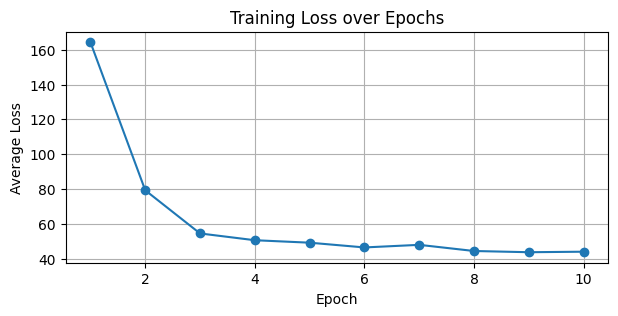

Input shapes: visual=torch.Size([32, 3, 32, 32]), joint=torch.Size([32, 185, 1, 7]), task=torch.Size([32, 165, 7, 6])
CNN output shape: torch.Size([32, 256])
Joint output shape: torch.Size([32, 64])
Task output shape: torch.Size([32, 64])
Combined shape: torch.Size([32, 384])
Final output shape: torch.Size([32, 8])


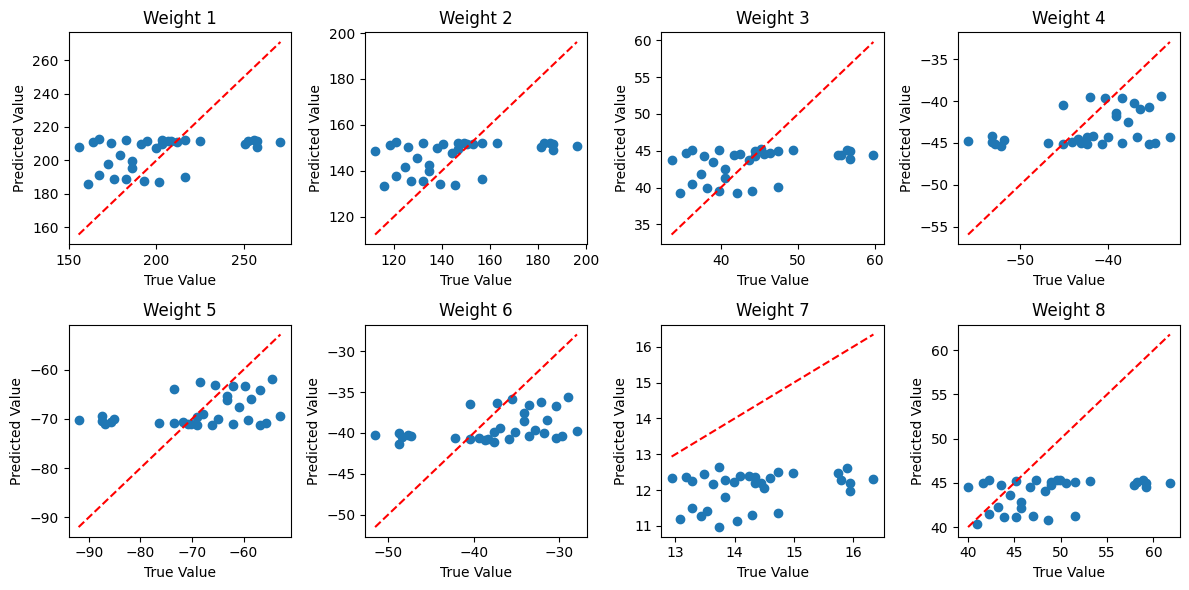

Model saved successfully.


In [ ]:
def train_model(model, train_loader, num_epochs, learning_rate):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    losses = []

    for epoch in range(num_epochs):
        total_loss = 0
        for i, (visuals, weights, traj_joint, traj_task) in enumerate(train_loader):

            # Forward pass
            outputs = model(visuals, traj_joint, traj_task)

            # Calculate loss
            loss = euclidean_loss(outputs, weights)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            if (i+1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}')

    return losses

# Visualization functions
def plot_loss(losses):
    plt.figure(figsize=(7, 3))
    plt.plot(range(1, len(losses) + 1), losses, marker='o')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Average Loss')
    plt.grid(True)
    plt.show()

def plot_prediction_comparison(model, dataloader):
    model.eval()
    with torch.no_grad():
        visuals, weights, traj_joint, traj_task = next(iter(dataloader))
        outputs = model(visuals, traj_joint, traj_task)

    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.scatter(weights[:, i].cpu(), outputs[:, i].cpu())
        plt.plot([weights[:, i].min(), weights[:, i].max()], [weights[:, i].min(), weights[:, i].max()], 'r--')
        plt.title(f'Weight {i+1}')
        plt.xlabel('True Value')
        plt.ylabel('Predicted Value')
    plt.tight_layout()
    plt.show()


model = HybridModel(joint_weight_size=8)
losses = train_model(model, train_loader, num_epochs, learning_rate)

# Visualize the results
plot_loss(losses)
plot_prediction_comparison(model, train_loader)

# Save the model
torch.save(model.state_dict(), 'hybrid_model.pth')
print("Model saved successfully.")